# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from scipy.optimize import fsolve

# Equations

In [2]:
def di_over_ism(s_values, k_values):
    return k_values - 5 * s_values**2 / (12 * (s_values + 1)) # > 0 means direct inversion is better than iterative Sherman-Morisson

def di_over_wmi(s_values, k_values):
    return (5/6)*(k_values**3) + 4*s_values*k_values**2 + 2*(s_values**2 - s_values)*k_values - (5/6)*s_values**3 # > 0 means direct inversion is better than Woodbury Matrix Identity

def ism_over_wmi(s_values, k_values):
    return (5/6)*(k_values**3) + 4*s_values*k_values**2 - 4*s_values*k_values # > 0 means Iterative Sherman-Morisson is better than Woodbury Matrix Identity


def plot_eq(s_values, k_values, eq, colors, save_file = None):
    all_roots = np.zeros(len(s_values))
    for i, s in enumerate(s_values):
        f = lambda k : eq(s, k)
        roots = fsolve(f, 40)[0]
        all_roots[i] = roots

    a = all_roots[-1] / s_values[-1]
    print(f"k = {a:.4f}s      /     s = {1/a:.4f}k")

    X, Y = np.meshgrid(s_values, k_values)
    Z = Y >= a * X
    
    if np.all(Z == True): # Only values >= 0
        cmap = ListedColormap([colors[1]])
    elif np.all(Z == False): # Only values < 0
        cmap = ListedColormap([colors[0]])
    else:
        cmap = ListedColormap(colors)

    plt.figure(figsize=(12, 6))
    plt.pcolormesh(X, Y, Z, cmap=cmap, shading='auto', alpha=0.5)
    plt.plot(s_values, a*s_values, 'k--', label=f'k ≈ {a:.4f}s ≈ s/{1/a:.4f}')
    plt.xlabel("s (matrix size)")
    plt.ylabel("k (increment size)")
    plt.legend(loc="upper right")
    plt.ylim(0, k_values[-1])

    if save_file is not None:
        plt.savefig(save_file)
        
    plt.show()



# Parameters

## Colors

In [3]:
di_color = (1,0,0,0.5) # Red for direct inversion
ism_color = (0,1,0,0.5) # Green for Sherman-Morrison
wmi_color = (0,0,1,0.5) # Blue for Woodbury Matrix Identity

## Grid values

In [4]:
s_values = np.linspace(1, 10_000, 1000)
k_values = np.linspace(1, 4_200, 4200)

# Plots

## Direct inversion over Iterative Sherman-Morrison

k = 0.4166s      /     s = 2.4002k


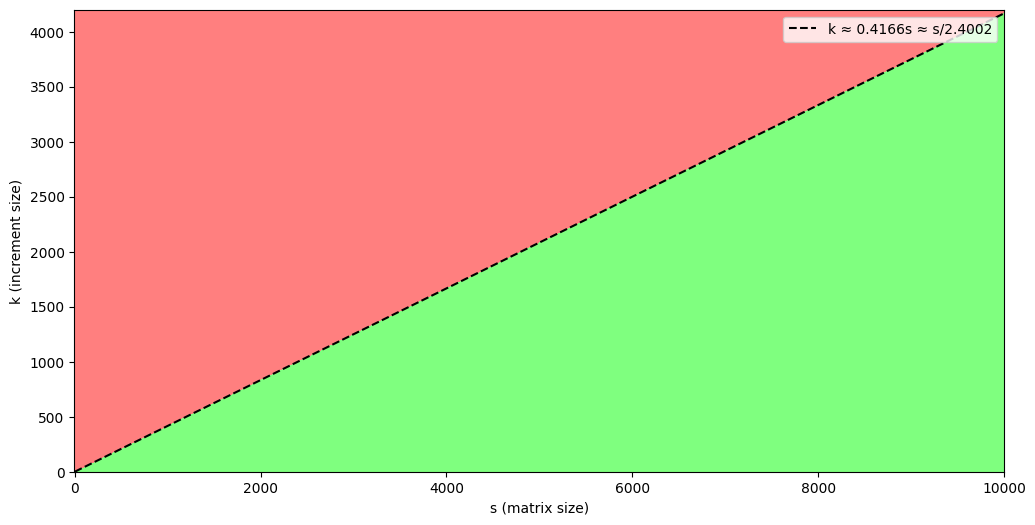

In [5]:
plot_eq(s_values, k_values, di_over_ism, [ism_color, di_color], save_file="images/di_vs_ism.png")

## Direct inversion over Woodbury Matrix Identity

k = 0.2666s      /     s = 3.7506k


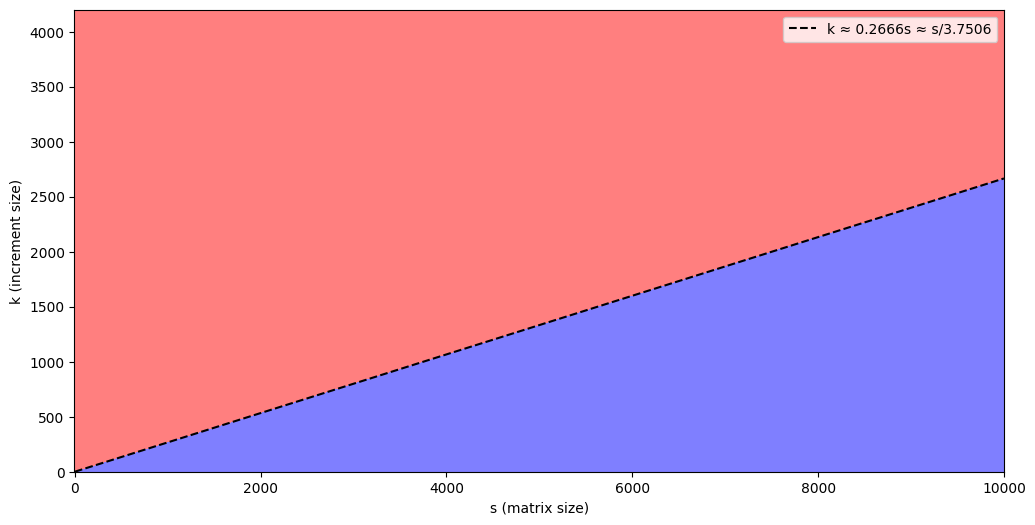

In [6]:
plot_eq(s_values, k_values, di_over_wmi, [wmi_color, di_color], save_file="images/di_vs_wmi.png")

## Iterative Sherman-Morrison over Woodbury Matrix Identity

k = 0.0001s      /     s = 10000.2083k


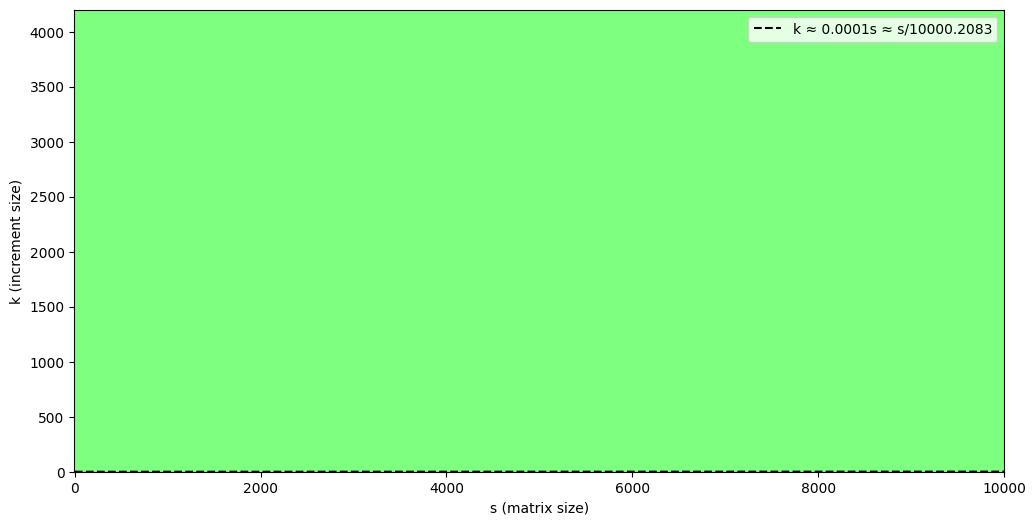

In [7]:
plot_eq(s_values, k_values, ism_over_wmi, [wmi_color, ism_color])

# Theoretical thresholds for k with s fixed to 1287

In [8]:
s_fixed = 1287

inversion_over_sherman = 5*s_fixed**2 / (12*(s_fixed+1))

f = lambda k: di_over_wmi(s_fixed, k)
inversion_over_woodbury = fsolve(f, 200)[0]
inversion_over_woodbury_empirical = s_fixed/3.7506

print(f"Thresholds for k with s = {s_fixed}:")
print(f"DI over ISM:           k > {inversion_over_sherman:.3f}")
print(f"DI over WMI:           k > {inversion_over_woodbury:.3f}")
print(f"DI over WMI empirical: k > {inversion_over_woodbury_empirical:.3f}")

Thresholds for k with s = 1287:
DI over ISM:           k > 535.834
DI over WMI:           k > 343.250
DI over WMI empirical: k > 343.145
